In [2]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import *
import requests
from sklearn.linear_model import LinearRegression
from sklearn.metrics import *
import warnings
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
import torch.optim as optim
from xgboost import train
import CONSTANTS
from functions import *
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.base import clone
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import warnings
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from xgboostImplementation import XGBoost
import pick
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv(fullDataPath(COIN))
data = data.loc[:, ~data.columns.str.contains('^Unnamed:')]
merged = dataSetup(data)
merged

,BB_Lower,BB_Upper,value,avg_sentiment,volume,OBV,SMA_7,Volume_MA_7,close,gradient
time,,,,,,,,,,
2015-07-20,268.225209,299.188791,52.0,0.000000,782.883420,-3.769640e+06,283.615714,4417.348637,280.00,0.00
2015-07-21,266.070954,300.106046,52.0,0.000000,4943.559434,-3.770423e+06,285.645714,5228.512882,277.32,-2.68
2015-07-22,263.804410,301.155590,52.0,0.000000,4687.909383,-3.765479e+06,288.280000,5345.414337,277.89,0.57
2015-07-23,263.024045,301.345955,52.0,0.000000,5306.919575,-3.770167e+06,290.037143,5421.928306,277.39,-0.50
2015-07-24,261.412051,301.912949,52.0,0.000000,7362.469083,-3.764860e+06,291.622857,5397.937160,289.12,11.73
...,...,...,...,...,...,...,...,...,...,...
2025-06-27,101939.424400,109261.342600,49.0,0.000477,6310.434926,-5.444307e+02,107148.120000,0.000000,107113.38,83.74
2025-06-28,101939.424400,109261.342600,49.0,0.004552,1227.768033,5.766004e+03,107148.120000,0.000000,107352.20,238.82
2025-06-29,101939.424400,109261.342600,50.0,4.106506,2154.861703,6.993772e+03,107148.120000,0.000000,108386.44,1034.24


# XGBoost Implementation

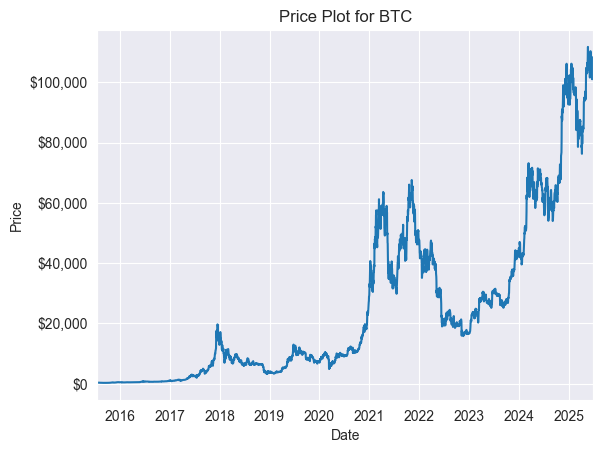

In [4]:
merged['close'].plot.line()
plt.title(f'Price Plot for {COIN}')
plt.xlabel('Date')
plt.ylabel('Price')
# format y axis to show currency
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))

In [5]:
scaler = StandardScaler()
closeScaler = StandardScaler()
mergedIndex = merged.index
mergedCols = merged.columns

mergedWithoutClose = merged.drop(columns=['close'])
mwocCols = mergedWithoutClose.columns
mwocIndex = mergedWithoutClose.index
mergedWithoutClose = scaler.fit_transform(mergedWithoutClose)
mergedWithoutClose = pd.DataFrame(mergedWithoutClose, index=mergedIndex, columns=mwocCols)

merged['close'] = closeScaler.fit_transform(merged['close'].values.reshape(-1, 1))
merged = pd.concat([mergedWithoutClose, merged['close']], axis=1)
merged

,BB_Lower,BB_Upper,value,avg_sentiment,volume,OBV,SMA_7,Volume_MA_7,gradient,close
time,,,,,,,,,,
2015-07-20,-0.886220,-0.928084,-0.068649,-0.012421,-1.147812,-1.988224,-0.909053,-1.128073,-0.026658,-0.908313
2015-07-21,-0.886305,-0.928053,-0.068649,-0.012421,-0.791394,-1.988899,-0.908978,-1.034309,-0.029124,-0.908411
2015-07-22,-0.886394,-0.928018,-0.068649,-0.012421,-0.813294,-1.984638,-0.908882,-1.020796,-0.026133,-0.908390
2015-07-23,-0.886425,-0.928012,-0.068649,-0.012421,-0.760267,-1.988678,-0.908818,-1.011952,-0.027118,-0.908408
2015-07-24,-0.886489,-0.927993,-0.068649,-0.012421,-0.584181,-1.984104,-0.908760,-1.014725,-0.015864,-0.907978
...,...,...,...,...,...,...,...,...,...,...
2025-06-27,3.127083,2.735922,-0.527361,-0.012117,-0.674302,1.260691,3.001942,-1.638681,0.050402,3.012165
2025-06-28,3.127083,2.735922,-0.527361,-0.009519,-1.109702,1.266131,3.001942,-1.638681,0.193111,3.020929
2025-06-29,3.127083,2.735922,-0.374457,2.605324,-1.030284,1.267189,3.001942,-1.638681,0.925081,3.058883


In [6]:
training_cols = trainingCols()
X = merged[training_cols]
y = merged['close']
n = len(data)

merged = transformerDataSetup(merged)
X_train, X_test, y_train, y_test, _, _ = transformerXTrainYTrain(merged, testSize=len(merged)-TEST_DAYS)
train_stuff = merged.loc[X_train.index, training_cols]
test_stuff = merged.loc[X_test.index, training_cols]
X_train_norm = pd.concat([X_train, train_stuff], axis=1)
X_test_norm = pd.concat([X_test, test_stuff], axis=1)

X_train_norm.shape, X_test_norm.shape, y_train.shape, y_test.shape

((3628, 9), (7, 9), (3628,), (7,))

In [7]:
xgb_model = XGBoost(
    base_estimator=RandomForestRegressor(n_estimators=50),
    n_estimators=50,
    learning_rate=0.1,
    max_depth=8,
    random_state=42,
)

RMSE = 1090.8030368217198


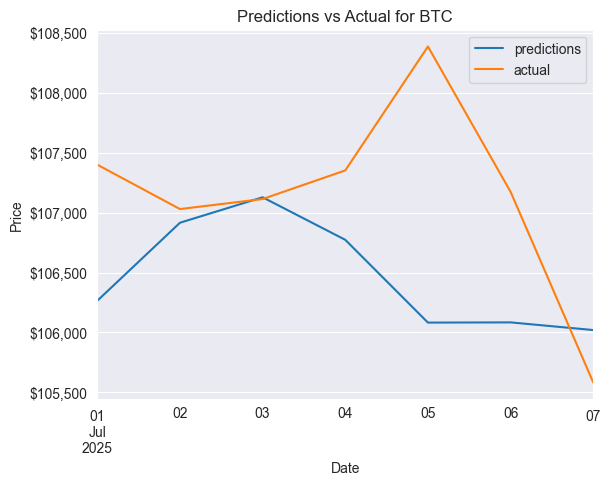

In [8]:
xgb_model.fit(X_train_norm, y_train)
predictions = xgb_model.predict(X_test_norm.iloc[[-1]]) # Predicting for the future 7 days
xgb_model.save(f'models/{COIN}_full_xgb_model_everything.pkl')

predictions = np.array(predictions)
predictions = predictions.reshape(-1, 1)
predictions = closeScaler.inverse_transform(predictions)
predictions = pd.DataFrame(predictions, columns=['predictions'])
predictions.index = pd.date_range(start=merged.index.max(), periods=TEST_DAYS, freq='D')
if not os.path.exists(f'predictions/{COIN}'):
    os.makedirs(f'predictions/{COIN}')
predictions.to_csv(f'predictions/{COIN}/xgb_predictions.csv')
predictions.plot.line()
plt.title(f'Predictions from XGB for {COIN}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))
plt.show()

In [15]:
predictions_1 = xgb_model.predict(X_test_norm.iloc[[-2]])
predictions_1 = np.array(predictions_1)
predictions_1 = predictions_1.reshape(-1, 1)
predictions_1 = closeScaler.inverse_transform(predictions_1)
predictions_1 = pd.DataFrame(predictions_1, columns=['predictions'])
predictions_1['actual'] = closeScaler.inverse_transform(np.array(y_test.iloc[-2]).reshape(-1, 1))

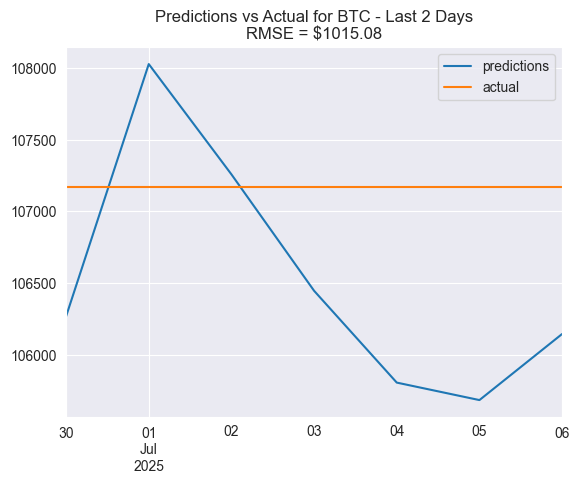

In [29]:
predictions_1.index = pd.date_range(merged.index.max()-pd.Timedelta(days=1), periods=len(predictions_1), freq='D')
predictions_1.plot.line()
mse = mean_squared_error(predictions_1['actual'], predictions_1['predictions'], squared=False)
plt.title(f'Predictions vs Actual for {COIN} - Last 2 Days\nRMSE = ${mse:.2f}')
plt.show()